In [2]:
# Step 1: Load the data set in collab
from google.colab import files
uploaded = files.upload()


Saving Data Set (1).xlsx to Data Set (1).xlsx


In [ ]:
# Step 2: Upload pandas

!pip install pandas scikit-learn matplotlib openpyxl

In [5]:
#Step 2: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

In [6]:
# Step 3: Load & Explore Data
file_path = "Data Set (1).xlsx"
df = pd.read_excel(file_path, sheet_name="DataSet")

print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nClass distribution (Fraud):\n{df['Fraud'].value_counts()}")
print(f"Fraud rate: {df['Fraud'].mean() * 100:.2f}%")

=== Dataset Overview ===
Shape: (100000, 12)

Column names:
['Customer_Name', 'Mobile_Number', 'Age', 'Transaction_Amount', 'Account_Balance', 'Transaction_Type', 'Merchant_Category', 'Transaction_Time', 'Transaction_Location', 'Device_Type', '% of account balance', 'Fraud']

First 5 rows:
   Customer_Name  Mobile_Number  Age  Transaction_Amount  Account_Balance  \
0  Lakshit Sheth     6289193523   66              482577           553658   
1   Saksham Kata     6451776549   28              442864           940972   
2     Vidur Saha     7851869818   28              196974           186582   
3   Tarini Kunda     9176006676   53              286390           131351   
4     Himmat Dua     9036326011   21               21673           159633   

  Transaction_Type Merchant_Category Transaction_Time Transaction_Location  \
0   ATM Withdrawal            Retail         00:23:17        Visakhapatnam   
1  Online Purchase       Electronics         12:02:07               Kanpur   
2  POS Trans

In [7]:
# Step 4: Feature Engineering
# Use all available numeric features instead of hardcoding 3
# Drop non-numeric or ID columns if they exist (adjust names as needed)
columns_to_drop = ["Fraud"]

# Optional: add engineered features
df["Balance_to_Amount_Ratio"] = df["Account_Balance"] / (df["Transaction_Amount"] + 1)
df["High_Amount_Flag"] = (df["Transaction_Amount"] > df["Transaction_Amount"].quantile(0.90)).astype(int)

X = df.drop(columns=columns_to_drop)
y = df["Fraud"]

print(f"\n=== Features Used ===\n{X.columns.tolist()}")


=== Features Used ===
['Customer_Name', 'Mobile_Number', 'Age', 'Transaction_Amount', 'Account_Balance', 'Transaction_Type', 'Merchant_Category', 'Transaction_Time', 'Transaction_Location', 'Device_Type', '% of account balance', 'Balance_to_Amount_Ratio', 'High_Amount_Flag']


In [8]:
# Step 5: Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Fraud in train: {y_train.sum()}  |  Fraud in test: {y_test.sum()}")


Train size: 80000  |  Test size: 20000
Fraud in train: 20099  |  Fraud in test: 5025


In [10]:
# Step 6: Handle Class Imbalance with SMOTE
print("\n=== Class Distribution Before SMOTE ===")
print(y_train.value_counts())

# The error "ValueError: could not convert string to float" indicates that
# SMOTE received non-numeric columns.
# We need to ensure X_train and X_test contain only numeric data.
# Identify numeric columns
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Filter X_train and X_test to include only these numeric columns
X_train = X_train[numeric_cols]
X_test = X_test[numeric_cols] # Update X_test for consistency in subsequent steps

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\n=== Class Distribution After SMOTE ===")
print(pd.Series(y_train_res).value_counts())


=== Class Distribution Before SMOTE ===
Fraud
0    59901
1    20099
Name: count, dtype: int64

=== Class Distribution After SMOTE ===
Fraud
1    59901
0    59901
Name: count, dtype: int64


In [11]:
# Step 7: Feature Scaling
# Critical for Logistic Regression — without this, large-scale
# features (Transaction_Amount) dominate the optimization.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)          # Use fit from train only!

In [12]:
# Step 8: Train Multiple Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, clf in models.items():
    # Logistic Regression needs scaled data; tree models don't require it
    # but scaled data doesn't hurt them either — using same data for fair comparison
    clf.fit(X_train_scaled, y_train_res)
    y_pred = clf.predict(X_test_scaled)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "model":     clf,
        "y_pred":    y_pred,
        "y_prob":    y_prob,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "AUC-ROC":   roc_auc_score(y_test, y_prob),
    }

print("\n=== Model Comparison ===")
comparison_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ["model", "y_pred", "y_prob"]}
    for name, res in results.items()
}).T.round(4)
print(comparison_df)


=== Model Comparison ===
                     Accuracy  Precision  Recall      F1  AUC-ROC
Logistic Regression    0.9930     0.9809  0.9912  0.9860   0.9998
Random Forest          0.9977     0.9990  0.9918  0.9954   1.0000


In [13]:
# Step 9: Cross-Validation (more reliable than single split)
print("\n=== 5-Fold Cross-Validation (F1 Score) ===")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in models.items():
    # Re-instantiate to get fresh model for CV
    fresh_clf = type(clf)(**clf.get_params())
    cv_scores = cross_val_score(fresh_clf, X_train_scaled, y_train_res, cv=cv, scoring="f1")
    print(f"{name}: mean={cv_scores.mean():.4f}  std=±{cv_scores.std():.4f}  scores={cv_scores.round(4)}")


=== 5-Fold Cross-Validation (F1 Score) ===
Logistic Regression: mean=0.9943  std=±0.0003  scores=[0.9945 0.9938 0.9942 0.9948 0.994 ]
Random Forest: mean=0.9980  std=±0.0003  scores=[0.998  0.9975 0.9984 0.9981 0.9978]


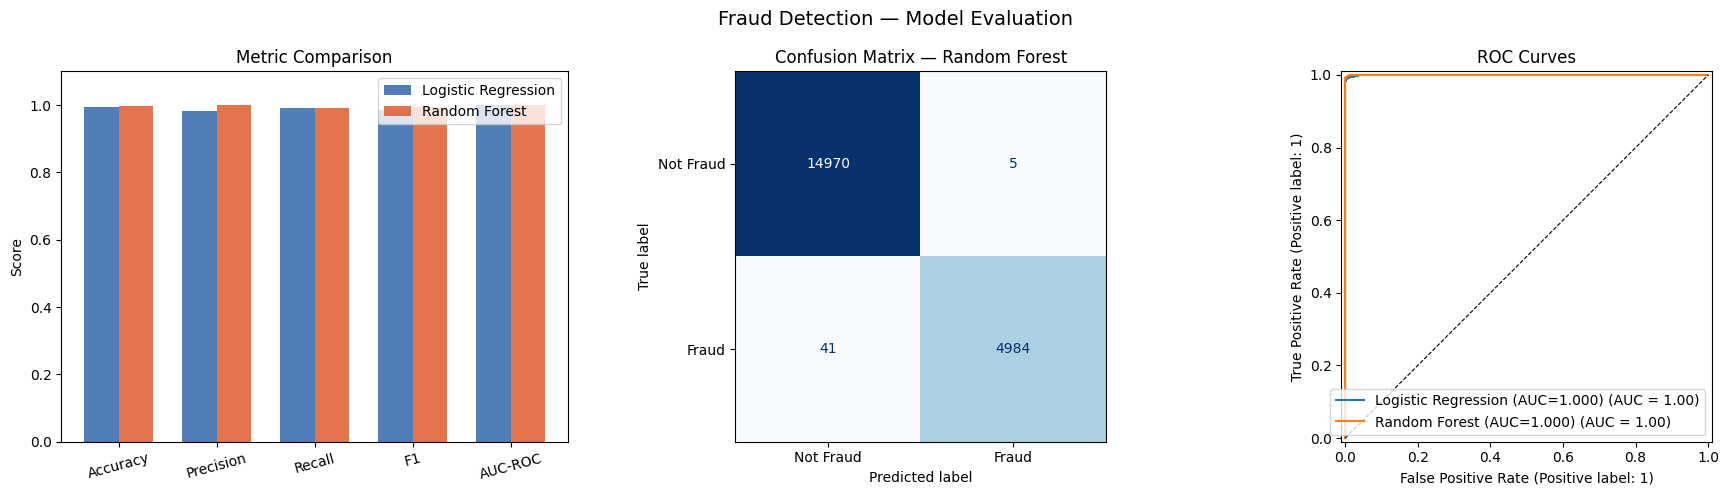

Plot saved as model_evaluation.png


In [14]:
# Step 10: Visualise Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Fraud Detection — Model Evaluation", fontsize=14)

# 10a: Metric comparison bar chart
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
x = np.arange(len(metrics))
width = 0.35
colors = ["#3266ad", "#e05c2e"]

for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    axes[0].bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.85)

axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].set_ylim(0, 1.1)
axes[0].set_title("Metric Comparison")
axes[0].legend()
axes[0].set_ylabel("Score")

# 10b: Confusion matrix for best model (by AUC)
best_name = max(results, key=lambda n: results[n]["AUC-ROC"])
best_res   = results[best_name]
cm = confusion_matrix(y_test, best_res["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Fraud", "Fraud"])
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title(f"Confusion Matrix — {best_name}")

# 10c: ROC curves
for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res["y_prob"], name=f"{name} (AUC={res['AUC-ROC']:.3f})", ax=axes[2]
    )
axes[2].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[2].set_title("ROC Curves")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as model_evaluation.png")


=== Feature Importance (Random Forest) ===
                Feature  Importance
   % of account balance    0.447118
Balance_to_Amount_Ratio    0.386383
        Account_Balance    0.129336
     Transaction_Amount    0.031790
                    Age    0.003819
          Mobile_Number    0.001167
       High_Amount_Flag    0.000387


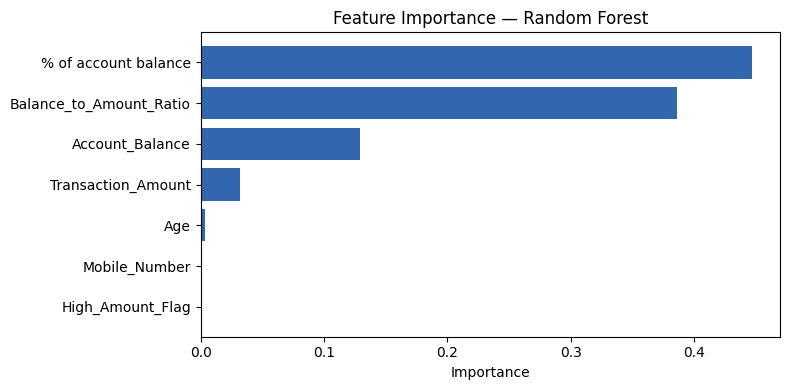

In [16]:
# Step 11: Feature Importance (Random Forest)
rf = results["Random Forest"]["model"]
importance_df = pd.DataFrame({
    "Feature":   numeric_cols,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\n=== Feature Importance (Random Forest) ===")
print(importance_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="#3266ad")
plt.xlabel("Importance")
plt.title("Feature Importance — Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Step 12: Logistic Regression Equation (scaled features)
lr = results["Logistic Regression"]["model"]
intercept = lr.intercept_[0]
coefficients = lr.coef_[0]

print("\n=== Logistic Regression Equation (on scaled features) ===")
print(f"Z = {intercept:.4f}", end=" ")
for feature, coef in zip(X.columns, coefficients):
    sign = "+" if coef >= 0 else "-"
    print(f"{sign} ({abs(coef):.4f} × {feature})", end=" ")
print()
print("Note: coefficients apply to StandardScaler-transformed values, not raw inputs.")


=== Logistic Regression Equation (on scaled features) ===
Z = -10.1118 + (0.0394 × Customer_Name) + (0.1717 × Mobile_Number) + (14.4956 × Age) - (30.0983 × Transaction_Amount) + (5.2763 × Account_Balance) + (0.2336 × Transaction_Type) - (0.1411 × Merchant_Category) 
Note: coefficients apply to StandardScaler-transformed values, not raw inputs.


In [19]:
# Step 13: Predict on a New Transaction
# Ensure new_transaction_raw contains all numeric columns used for training
# If some columns are not explicitly provided, sensible defaults are used.
new_transaction_data = {
    "Mobile_Number": [0],  # Assuming a placeholder for a new mobile number if not provided
    "Age": [25],
    "Transaction_Amount": [75000],
    "Account_Balance": [50000],
    "% of account balance": [75000 / 50000], # Calculate from provided values (Transaction_Amount / Account_Balance)
    "Balance_to_Amount_Ratio": [50000 / (75000 + 1)],
    "High_Amount_Flag": [1],   # Adjust based on the actual threshold if 75000 is above 90th percentile
}

new_transaction_raw = pd.DataFrame(new_transaction_data)

# Ensure column order matches the numeric columns used during training
new_transaction_raw = new_transaction_raw[numeric_cols]
new_transaction_scaled = scaler.transform(new_transaction_raw)

for name, res in results.items():
    prob = res["model"].predict_proba(new_transaction_scaled)[:, 1][0]
    pred = res["model"].predict(new_transaction_scaled)[0]
    print(f"\n[{name}]")
    print(f"  Fraud Probability : {prob:.4f}")
    print(f"  Prediction        : {'FRAUD' if pred == 1 else 'NOT FRAUD'}")


[Logistic Regression]
  Fraud Probability : 0.8809
  Prediction        : FRAUD

[Random Forest]
  Fraud Probability : 1.0000
  Prediction        : FRAUD
